<a href="https://colab.research.google.com/github/yxmauw/eye-disease-classification/blob/main/UNet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Setting up local directory to work
Stream data direct from kaggle using Kaggle API

In [1]:
# install kaggle API
!pip install kaggle

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


In [2]:
!git clone https://github.com/yxmauw/eye-disease-classification.git

fatal: destination path 'eye-disease-classification' already exists and is not an empty directory.


In [3]:
!mkdir ~/.kaggle #Make a directory named “.kaggle”

mkdir: cannot create directory ‘/root/.kaggle’: File exists


In [4]:
!cp ./eye-disease-classification/kaggle.json ~/.kaggle/ # Copy the “kaggle.json” into this new directory

In [5]:
!chmod 600 ~/.kaggle/kaggle.json # Allocate the required permission for this file

In [6]:
!kaggle datasets download gunavenkatdoddi/eye-diseases-classification # download dataset

eye-diseases-classification.zip: Skipping, found more recently modified local copy (use --force to force download)


In [7]:
! unzip eye-diseases-classification.zip

Archive:  eye-diseases-classification.zip
replace dataset/cataract/0_left.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

## Explore images

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_style('whitegrid')
%config InlineBackend.figure_format = 'retina'

### Number of images in dataset:

In [9]:
import fnmatch
import os

# image files count
cataract_count = len(fnmatch.filter(os.listdir('./dataset/cataract'), '*.jpg'))
dre_count = len(fnmatch.filter(os.listdir('./dataset/diabetic_retinopathy'), '*.jpeg'))
glaucoma_count = len(fnmatch.filter(os.listdir('./dataset/glaucoma'), '*.jpg'))
normal_count = len(fnmatch.filter(os.listdir('./dataset/normal'), '*.jpg'))
total_image_count = cataract_count + dre_count + \
                    glaucoma_count + normal_count
# print count
print('---Categories---')
print('Cataract:', cataract_count)
print('Diabetic retinopathy:', dre_count)
print('Glaucoma:', glaucoma_count)
print('Normal', normal_count)
print()
print('---Total image count---')
print(total_image_count)

---Categories---
Cataract: 938
Diabetic retinopathy: 1098
Glaucoma: 906
Normal 1074

---Total image count---
4016


### Image dimensions, properties:

In [10]:
# load example image
from PIL import Image 
im = Image.open('./dataset/glaucoma/1495_left.jpg')
# summarize some details about the image
print(im.format)
print(im.mode)
print(im.size) # size already 512 x 512

pixels = np.asarray(im)
print(pixels[0])
print(pixels.shape) # 3 channel last

JPEG
RGB
(512, 512)
[[0 0 0]
 [0 0 0]
 [0 0 0]
 ...
 [0 0 0]
 [0 0 0]
 [0 0 0]]
(512, 512, 3)


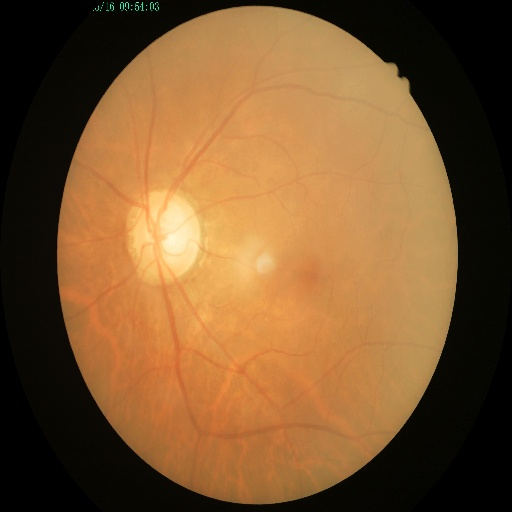

In [11]:
#Import library
from IPython import display
display.Image(filename='./dataset/glaucoma/1495_left.jpg', width=200, height=150)

In [12]:
# calculate image pixel mean, min, max

mean = pixels.mean()
print('Mean: %.3f' % mean)
# confirm pixel range is 0-255
print('Min: %.3f, Max: %.3f' % (pixels.min(), pixels.max()))

Mean: 86.173
Min: 0.000, Max: 255.000


## Visualise preprocessed images

In [13]:
import tensorflow as tf
from tensorflow.keras import layers
print(tf.__version__) #2.8.2

2.8.2


What happens after resizing and rescaling: 

In [14]:
resize_and_rescale = tf.keras.Sequential([   
    layers.Resizing(160,160) ,  # needs to be symmetrical
    layers.Rescaling(1./255) # desired height, width in model pipeline
])

result = resize_and_rescale(pixels)
print(result.shape) # new shape, channels

(160, 160, 3)


What happens to image pixel values after rescaling:

In [15]:
print("Min and max pixel values:", result.numpy().min(), result.numpy().max())

Min and max pixel values: 0.0 1.0


Show images before and after preprocessing:

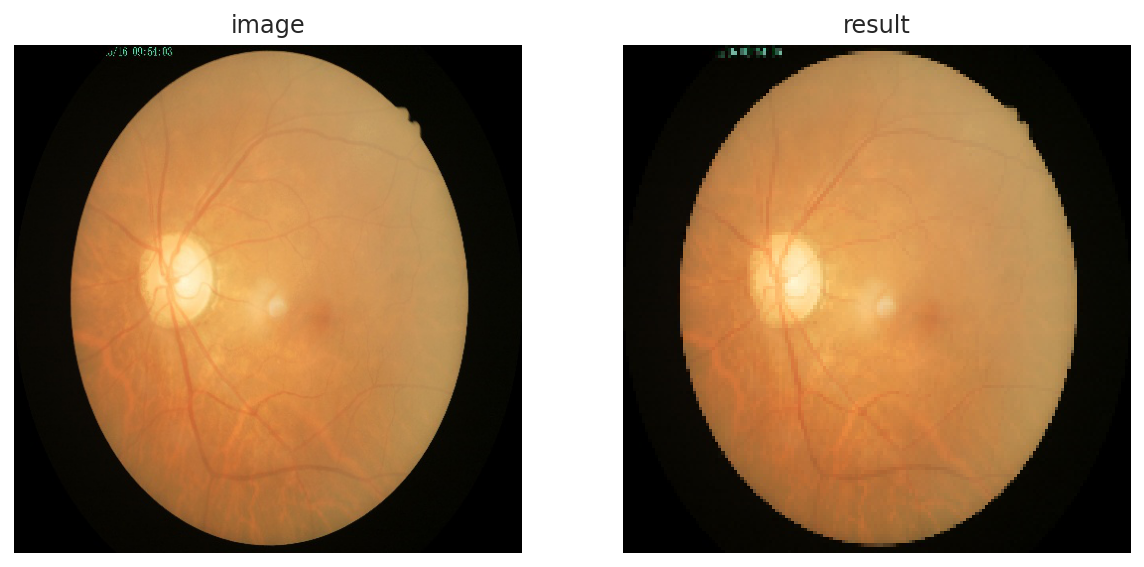

In [16]:
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(10,8))
ax0.imshow(im)
ax0.axis('off')
ax0.set_title('image')
# after pixel normalisation
ax1.imshow(result)
ax1.axis('off')
ax1.set_title('result')
plt.show() # result seems to have slight blurring of image, but still good definition

## Create train and validation datasets

In [17]:
# generate dataset that can be used for machine learning
from tensorflow.keras.utils import image_dataset_from_directory

image_size = (160, 160) # very important to get this right, will determine model success
batch_size = 32

train_ds = image_dataset_from_directory(
    './dataset/',
    image_size=image_size,
    shuffle=True,
    seed=1,
    batch_size=batch_size,
    validation_split=0.2,
    subset="training",
    label_mode='categorical'
)

val_ds = image_dataset_from_directory(
    './dataset/',
    image_size=image_size,
    shuffle=True,
    seed=1,
    batch_size=batch_size,
    validation_split=0.2,
    subset="validation",
    label_mode='categorical'
)

Found 4217 files belonging to 4 classes.
Using 3374 files for training.
Found 4217 files belonging to 4 classes.
Using 843 files for validation.


### Visualise images and labels together

In [ ]:
# preview of how images are labelled
class_names = train_ds.class_names
print(class_names)

plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1): # each image 160 x 160
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[tf.argmax(labels[i], axis=0)])
    plt.axis("off")

['cataract', 'diabetic_retinopathy', 'glaucoma', 'normal']


## Configure datasets for optimal performance

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

## Data augmentation

In [ ]:
data_augmentation = tf.keras.Sequential(
    [ layers.RandomFlip("horizontal_and_vertical", seed=1), 
      layers.RandomRotation(0.2, seed=2),
      layers.RandomContrast(0.1, seed=3)
    ])

### Visualise augmented images

In [ ]:
def augmented_img():
  for image, _ in train_ds.take(1):  # take a sample image from training set
    plt.figure(figsize=(8, 8))
    first_image = image[0]
    for i in range(9):
      ax = plt.subplot(3, 3, i + 1)
      augmented_image = data_augmentation(tf.expand_dims(first_image, 0))
      plt.imshow(augmented_image[0] / 255) # rescale pixel 0 to 1
      plt.axis("off")

In [ ]:
augmented_img()

## Create Base UNet model

[UNet code architecture](https://blog.paperspace.com/unet-architecture-image-segmentation/)

<img src="https://miro.medium.com/max/1020/1*_azTISV4DteZd8hCSiQ7Dg.png" alt="UNet model" width="500" height="300">


In [ ]:
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Activation, ReLU
from tensorflow.keras.layers import BatchNormalization, Conv2DTranspose, Concatenate
from tensorflow.keras.models import Model, Sequential

In [ ]:
def convolution_operation(entered_input, filters=64):
    # Taking first input and implementing the first conv block
    conv1 = Conv2D(filters, kernel_size = (3,3), padding = "same")(entered_input)
    batch_norm1 = BatchNormalization()(conv1)
    act1 = ReLU()(batch_norm1)
    
    # Taking first input and implementing the second conv block
    conv2 = Conv2D(filters, kernel_size = (3,3), padding = "same")(act1)
    batch_norm2 = BatchNormalization()(conv2)
    act2 = ReLU()(batch_norm2)
    
    return act2

In [ ]:
def encoder(entered_input, filters=64):
    # Collect the start and end of each sub-block for normal pass and skip connections
    enc1 = convolution_operation(entered_input, filters)
    MaxPool1 = MaxPooling2D(strides = (2,2))(enc1)
    return enc1, MaxPool1

In [ ]:
def decoder(entered_input, skip, filters=64):
    # Upsampling and concatenating the essential features
    Upsample = Conv2DTranspose(filters, (2, 2), strides=2, padding="same")(entered_input)
    Connect_Skip = Concatenate()([Upsample, skip])
    out = convolution_operation(Connect_Skip, filters)
    return out

In [ ]:
def U_Net(Image_Size): # without data augmentation
    # Take the image size and shape
    input1 = tf.keras.Input(Image_Size)
    # rescale
    input1 = layers.Rescaling(1./255)(input1)

    # Construct the encoder blocks
    skip1, encoder_1 = encoder(input1, 64)
    skip2, encoder_2 = encoder(encoder_1, 64*2)
    skip3, encoder_3 = encoder(encoder_2, 64*4)
    skip4, encoder_4 = encoder(encoder_3, 64*8)
    
    # Preparing the next block
    conv_block = convolution_operation(encoder_4, 64*16)
    
    # Construct the decoder blocks
    decoder_1 = decoder(conv_block, skip4, 64*8)
    decoder_2 = decoder(decoder_1, skip3, 64*4)
    decoder_3 = decoder(decoder_2, skip2, 64*2)
    decoder_4 = decoder(decoder_3, skip1, 64)
    
    out_1 = Conv2D(4, 1, padding="same", activation="relu")(decoder_4)
    #final layers to force shape to suit binary label shapes
    flat = tf.keras.layers.Flatten()(out_1)
    out_2 = tf.keras.layers.Dense(4, activation='softmax')(flat)

    model = Model(input1, out_2)
    return model

In [ ]:
input_shape = (160, 160, 3)
model = U_Net(input_shape)
model.summary()

In [ ]:
# show model in graph manner
keras.utils.plot_model(model, to_file = "Model.png", show_shapes=True)

## Compile, fit model, run

In [ ]:
model.compile(optimizer='adam', 
              loss="categorical_crossentropy", # match label_mode='categorical'
              metrics=['accuracy','AUC'])

# Train the model, doing validation at the end of each epoch.
epochs = 10

callbacks = [
    tf.keras.callbacks.ModelCheckpoint("saved_epoch{epoch}.h5", save_best_only=True),
    tf.keras.callbacks.EarlyStopping(monitor='val_loss',mode='min',verbose=1,patience=3,min_delta=1,restore_best_weights=True)
]

history = model.fit(train_ds, epochs=epochs, validation_data=val_ds, callbacks=callbacks)

## Finetune model

In [ ]:
def U_Net_finetuned(Image_Size):
    # Take the image size and shape
    input1 = tf.keras.Input(Image_Size)
    # data augmentation
    input1 = data_augmentation(input1)
    # rescale
    input1 = layers.Rescaling(1./255)(input1)

    # Construct the encoder blocks
    skip1, encoder_1 = encoder(input1, 64)
    skip2, encoder_2 = encoder(encoder_1, 64*2)
    skip3, encoder_3 = encoder(encoder_2, 64*4)
    skip4, encoder_4 = encoder(encoder_3, 64*8)
    
    # Preparing the next block
    conv_block = convolution_operation(encoder_4, 64*16)
    
    # Construct the decoder blocks
    decoder_1 = decoder(conv_block, skip4, 64*8)
    decoder_2 = decoder(decoder_1, skip3, 64*4)
    decoder_3 = decoder(decoder_2, skip2, 64*2)
    decoder_4 = decoder(decoder_3, skip1, 64)
    
    out_1 = Conv2D(4, 1, padding="same", activation="relu")(decoder_4)
    #final layers to force shape to suit binary label shapes
    flat = tf.keras.layers.Flatten()(out_1)
    out_2 = tf.keras.layers.Dense(4, activation='softmax')(flat)

    model = Model(input1, out_2)
    return model

In [ ]:
input_shape = (160, 160, 3)
model = U_Net_finetuned(input_shape)
model.summary()

## Compile, fit model, run

In [ ]:
model.compile(optimizer='adam', 
              loss="categorical_crossentropy", # match label_mode='categorical'
              metrics=['accuracy','AUC'])

# Train the model, doing validation at the end of each epoch.
epochs = 10

callbacks = [
    tf.keras.callbacks.ModelCheckpoint("model_finetuned{epoch}.h5", save_best_only=True),
    tf.keras.callbacks.EarlyStopping(monitor='val_loss',mode='min',verbose=1,patience=3,min_delta=1,restore_best_weights=True)
]

history = model.fit(train_ds, epochs=epochs, validation_data=val_ds, callbacks=callbacks)

## Evaluation

__References:__
1. [images](https://machinelearningmastery.com/image-augmentation-with-keras-preprocessing-layers-and-tf-image/)
1. [kaggle code](https://www.kaggle.com/code/gpiosenka/eye-disease-f1-score-92-6/notebook)